In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import expit
from scipy.stats import norm

In [30]:
data = pd.read_excel("data/MultinomialData40.xlsx")
# data = data.values

In [31]:
data

,Y,X1
0,1,10
1,1,11
2,0,16
3,1,10
4,1,9
...,...,...
1495,0,10
1496,0,15
1497,1,14
1498,1,16


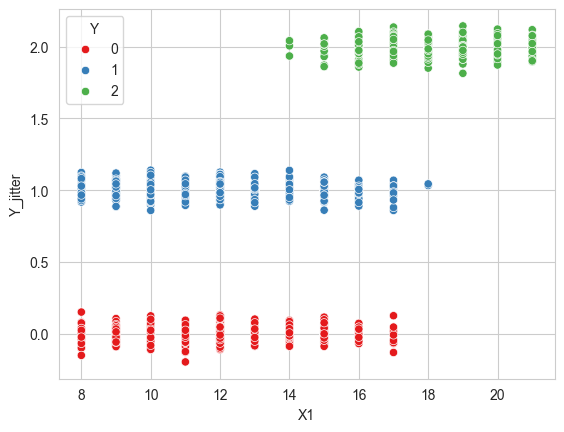

In [34]:
data["Y_jitter"] = data["Y"] + np.random.normal(0, 0.05, size=len(data))
sns.scatterplot(data=data, x="X1", y="Y_jitter", hue="Y", palette="Set1")
plt.show()

In [35]:
# Count number of occurrence of each Y.
# Y=0 administrative in A
# Y=1 administrative in B
# Y=2 management
data.groupby('Y').count()

,X1,Y_jitter
Y,,
0,486,486
1,476,476
2,538,538


## 1.e Ordered logit model

In [36]:
data_np = data.values
g_y = data_np[:, 0]
g_y = (g_y == 1) * 0 + (g_y == 0) * 1 + (g_y == 2) * 2  # admin, custodial were y=0,1
g_x1 = data_np[:, 1]

In [37]:
def MinusLogLOrderedProbit(par, g_y, g_x1):
    beta1 = par[0]
    tau1 = par[1]
    tau2 = par[2]

    if tau1 >= tau2:
        return 10 ** 10  # to prevent tau_1 >= tau_2

    Pr_y_is_0_given_x = norm.cdf(tau1 - beta1 * g_x1)
    Pr_y_is_1_given_x = norm.cdf(tau2 - beta1 * g_x1) - \
                        norm.cdf(tau1 - beta1 * g_x1)
    Pr_y_is_2_given_x = 1 - norm.cdf(tau2 - beta1 * g_x1)
    Pr_y_given_x = (Pr_y_is_0_given_x ** (g_y == 0)) * \
                   (Pr_y_is_1_given_x ** (g_y == 1)) * \
                   (Pr_y_is_2_given_x ** (g_y == 2))
    loglikelihood = np.sum(np.log(Pr_y_given_x))
    return -loglikelihood

In [38]:
# Initial values for numerical optimization:
beta1_ini = 0.0
tau1_ini = -1.0
tau2_ini = 1.0
par_ini = [beta1_ini, tau1_ini, tau2_ini]
# Estimation: MINimize function MinusLogLOrderedProbit:
EstimationResult = minimize(MinusLogLOrderedProbit, par_ini, args=(g_y, g_x1), method="BFGS")
par_MLE = EstimationResult.x

In [39]:
par_MLE

array([0.30701243, 3.57092613, 4.93431128])

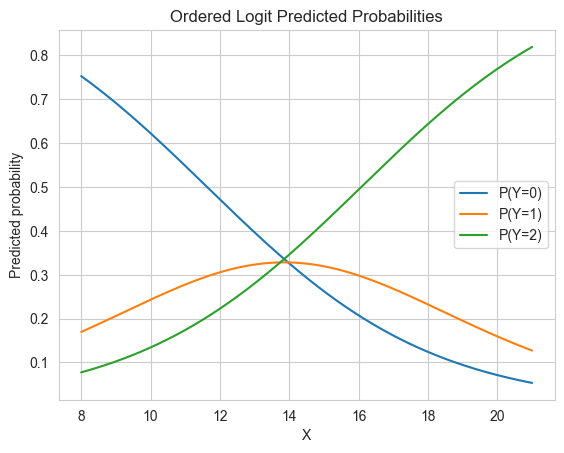

In [40]:
# Your estimated parameters
beta = par_MLE[0]
tau1 = par_MLE[1]
tau2 = par_MLE[2]

# Grid of X values
x_grid = np.linspace(data["X1"].min(), data["X1"].max(), 300)

# Predicted probabilities
P0 = expit(tau1 - beta * x_grid)
P1 = expit(tau2 - beta * x_grid) - expit(tau1 - beta * x_grid)
P2 = 1 - expit(tau2 - beta * x_grid)

# Plot
plt.plot(x_grid, P0, label="P(Y=0)")
plt.plot(x_grid, P1, label="P(Y=1)")
plt.plot(x_grid, P2, label="P(Y=2)")

plt.xlabel("X")
plt.ylabel("Predicted probability")
plt.legend()
plt.title("Ordered Logit Predicted Probabilities")
plt.show()

## 1.f Ordered logit model (opposite)

In [41]:
# data_ordered
data["Y"] = 2 - data["Y"]

In [42]:
# data["Y_jitter"] = data["Y"] + np.random.normal(0, 0.05, size=len(data))
# sns.scatterplot(data=data, x="X1", y="Y_jitter", hue="Y", palette="Set1")
# plt.show()

In [43]:
data_np = data.values
g_y = data_np[:, 0]
g_y = (g_y == 1) * 0 + (g_y == 0) * 1 + (g_y == 2) * 2  # admin, custodial were y=0,1
g_x1 = data_np[:, 1]

In [44]:
def MinusLogLOrderedProbitOpposite(par, g_y, g_x1):
    beta1 = par[0]
    tau1 = par[1]
    tau2 = par[2]

    if tau1 <= tau2:
        return 10 ** 10  # to prevent tau_1 >= tau_2

    Pr_y_is_0_given_x = norm.cdf(- tau1 + beta1 * g_x1)
    Pr_y_is_1_given_x = norm.cdf(- tau2 + beta1 * g_x1) - \
                        norm.cdf(- tau1 + beta1 * g_x1)
    Pr_y_is_2_given_x = 1 - norm.cdf(- tau2 + beta1 * g_x1)
    Pr_y_given_x = (Pr_y_is_0_given_x ** (g_y == 0)) * \
                   (Pr_y_is_1_given_x ** (g_y == 1)) * \
                   (Pr_y_is_2_given_x ** (g_y == 2))
    loglikelihood = np.sum(np.log(Pr_y_given_x))
    return -loglikelihood

In [45]:
# Initial values for numerical optimization:
beta1_ini = 0.0
tau1_ini = 1.0
tau2_ini = -1.0
par_ini = [beta1_ini, tau1_ini, tau2_ini]
# Estimation: MINimize function MinusLogLOrderedProbit:
EstimationResult = minimize(MinusLogLOrderedProbitOpposite, par_ini, args=(g_y, g_x1), method="BFGS")
par_MLE = EstimationResult.x

In [46]:
par_MLE

array([ 0.00249156,  0.51199195, -0.4197471 ])

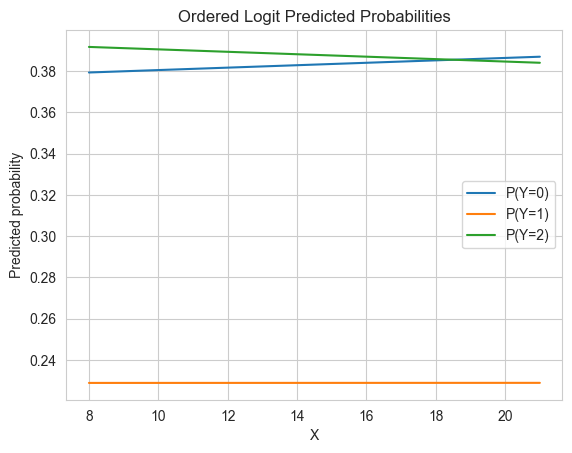

In [47]:
# Your estimated parameters
beta = par_MLE[0]
tau1 = par_MLE[1]
tau2 = par_MLE[2]

# Grid of X values
x_grid = np.linspace(data["X1"].min(), data["X1"].max(), 300)

# Predicted probabilities
P0 = expit(- tau1 + beta * x_grid)
P1 = expit(- tau2 + beta * x_grid) - expit(- tau1 + beta * x_grid)
P2 = 1 - expit(- tau2 + beta * x_grid)

# Plot
plt.plot(x_grid, P0, label="P(Y=0)")
plt.plot(x_grid, P1, label="P(Y=1)")
plt.plot(x_grid, P2, label="P(Y=2)")

plt.xlabel("X")
plt.ylabel("Predicted probability")
plt.legend()
plt.title("Ordered Logit Predicted Probabilities")
plt.show()

## 1.g Multinomial logit model

In [48]:
def MinusLogLMultinomialLogit(par, g_y, g_x1):
    beta0_1 = par[0]
    beta1_1 = par[1]
    beta0_2 = par[2]
    beta1_2 = par[3]
    exp_xbeta1 = np.exp(beta0_1 + beta1_1 * g_x1)
    exp_xbeta2 = np.exp(beta0_2 + beta1_2 * g_x1)
    Pr_y_is_0_given_x = 1 / (1 + exp_xbeta1 + exp_xbeta2)
    Pr_y_is_1_given_x = exp_xbeta1 / (1 + exp_xbeta1 + exp_xbeta2)
    Pr_y_is_2_given_x = exp_xbeta2 / (1 + exp_xbeta1 + exp_xbeta2)
    Pr_y_given_x = (Pr_y_is_0_given_x ** (g_y == 0)) * \
                   (Pr_y_is_1_given_x ** (g_y == 1)) * \
                   (Pr_y_is_2_given_x ** (g_y == 2))
    loglikelihood = np.sum(np.log(Pr_y_given_x))
    return (-loglikelihood)

In [49]:
def estimate_multinomial_logit_model(data):
    data_np = data.values
    g_y = data_np[:, 0]
    g_x1 = data_np[:, 1]

    # Initial values for numerical optimization:
    par_ini = np.zeros(4)

    # Estimation: MINimize function MinusLogLOrderedProbit:
    EstimationResult = minimize(MinusLogLMultinomialLogit, par_ini, args=(g_y, g_x1), method="BFGS")
    return EstimationResult.x

In [50]:
def plot_multinomial_logit_model(par_MLE):
    # Estimated parameters
    beta0_1, beta1_1, beta0_2, beta1_2 = par_MLE
    # Grid of X values
    x_grid = np.linspace(g_x1.min(), g_x1.max(), 400)
    # Linear indices
    xb1 = beta0_1 + beta1_1 * x_grid
    xb2 = beta0_2 + beta1_2 * x_grid
    # Exponentials
    exp_xb1 = np.exp(xb1)
    exp_xb2 = np.exp(xb2)
    # Probabilities
    denom = 1 + exp_xb1 + exp_xb2
    P0 = 1 / denom
    P1 = exp_xb1 / denom
    P2 = exp_xb2 / denom
    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(x_grid, P0, label="P(Y=0)")
    plt.plot(x_grid, P1, label="P(Y=1)")
    plt.plot(x_grid, P2, label="P(Y=2)")
    plt.xlabel("X")
    plt.ylabel("Predicted probability")
    plt.title("Estimated Multinomial Logit Probabilities")
    plt.legend()
    plt.ylim(0, 1)
    plt.show()

### 1.g.1 Original order

In [51]:
par_MLE = estimate_multinomial_logit_model(data)
par_MLE

array([28.31325032, -1.79443891, 28.38434929, -1.79858737])

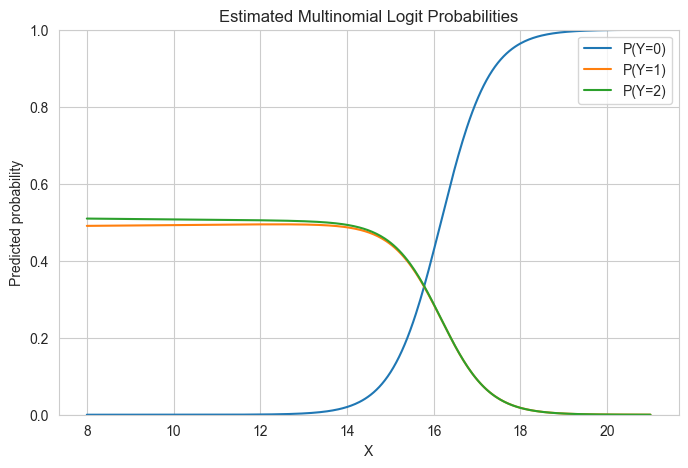

In [52]:
plot_multinomial_logit_model(par_MLE)

### 1.g.2 Change order to the opposite (2->0, 1->1, 0->2)

In [53]:
data["Y"] = 2 - data["Y"]
par_MLE = estimate_multinomial_logit_model(data)
par_MLE

array([-7.10916252e-02,  4.14784965e-03, -2.83842034e+01,  1.79857840e+00])

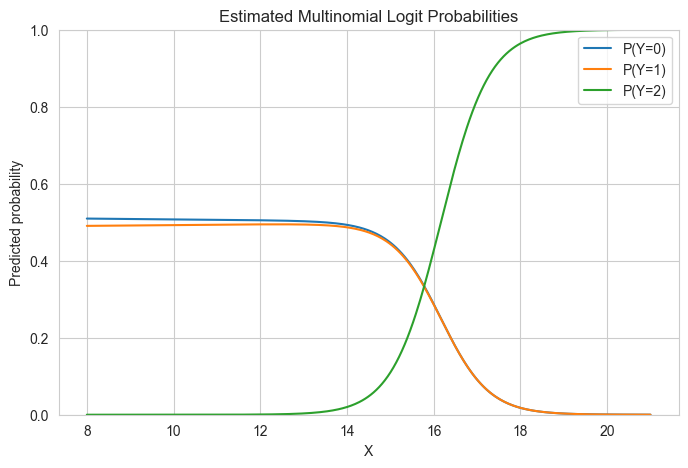

In [54]:
plot_multinomial_logit_model(par_MLE)

### 1.g.3 Change order to the (0->0, 2->1, 1->2)

In [55]:
data["Y"] = data["Y"].map({0: 0, 2: 1, 1: 2})
par_MLE = estimate_multinomial_logit_model(data)
par_MLE

array([-2.83842622e+01,  1.79858199e+00, -7.10984012e-02,  4.14841313e-03])

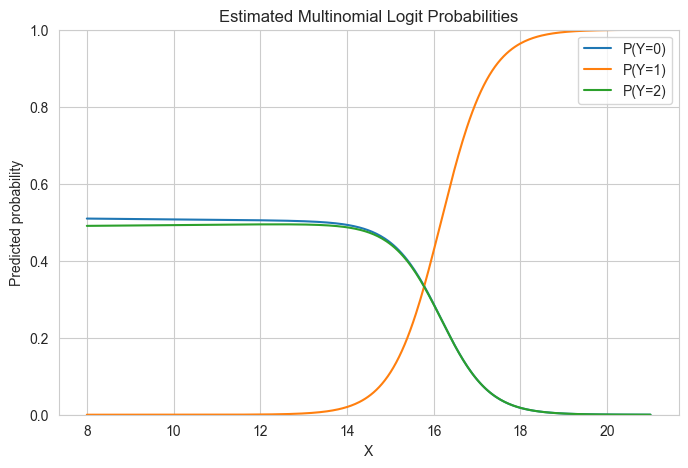

In [56]:
plot_multinomial_logit_model(par_MLE)